# Прогнозиране на добива от дива боровинка

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Задача

Целта на задачата е да се предвиди добива на дива боровинка на базата на климатични и екологични показатели. Вашата задача е да изберете подходящи характеристики и да обучите модел за регресия. Като примерни алгоритми са дадени kNN, Gradient Boosting и Multilayer Perceptron, но можете да изберете и друг алгоритъм. 

## Данни

#### Целева променлива: 
- **yield**- добив на дива боровинка 

#### Характеристики

- **clonesize (m²)** – среден размер на клона на боровинката  
- **honeybee (bees/m²/min)** – плътност на медоносни пчели  
- **bumbles (bees/m²/min)** – плътност на земни пчели (bumblebees)  
- **andrena (bees/m²/min)** – плътност на миньорни пчели (Andrena)  
- **osmia (bees/m²/min)** – плътност на зидарки (Osmia)  
- **MaxOfUpperTRange (°C)** – най-висока дневна температура (горна граница) по време на цъфтеж  
- **MinOfUpperTRange (°C)** – най-ниска дневна температура (горна граница)  
- **AverageOfUpperTRange (°C)** – средна дневна температура (горна граница)  
- **MaxOfLowerTRange (°C)** – най-висока дневна температура (долна граница)  
- **MinOfLowerTRange (°C)** – най-ниска дневна температура (долна граница)  
- **AverageOfLowerTRange (°C)** – средна дневна температура (долна граница)  
- **RainingDays (дни)** – общ брой дни с валежи по време на цъфтеж  
- **AverageRainingDays (дни)** – среден брой дни с валежи по време на цъфтеж
- **fruitset (%)** – процент на успешно завързани плодове от общия брой цветове
- **fruitmass (mg)** – средна маса на един плод (милиграмове)
- **seeds (брой/плод)** – среден брой семена на плод

## Оценяване 

Представените резултати ще бъдат оценявани чрез средната абсолютна грешка [(MAE)](https://en.wikipedia.org/wiki/Mean_absolute_error), 

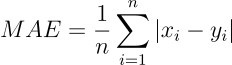 

където всеки $x_i$ представлява прогнозираната цел, $y_i$ представлява реалната стойност, а $n$ е броят на редовете в тестовия набор.

### Файл за представяне

За всеки идентификатор в тестовия набор трябва да прогнозирате целевия добив. Файлът трябва да съдържа заглавeн ред и да има следния формат:

```python
id,yield
15289,6025.194
15290,1256.223
15291,357.44
etc.
```



In [2]:
df = pd.read_csv("train.csv", index_col=0)
df.shape

(582, 17)

In [3]:
df.head()

,clonesize,honeybee,bumbles,andrena,osmia,MaxOfUpperTRange,MinOfUpperTRange,AverageOfUpperTRange,MaxOfLowerTRange,MinOfLowerTRange,AverageOfLowerTRange,RainingDays,AverageRainingDays,fruitset,fruitmass,seeds,yield
id,,,,,,,,,,,,,,,,,
0,25.0,0.50,0.38,0.50,0.63,77.4,46.8,64.7,55.8,27.0,45.8,1.0,0.10,0.551234,0.477127,39.332514,6842.760562
1,12.5,0.25,0.25,0.50,0.75,69.7,42.1,58.2,50.2,24.3,41.2,24.0,0.39,0.521907,0.432227,35.771139,6621.250814
2,25.0,0.50,0.25,0.50,0.75,86.0,52.0,71.9,62.0,30.0,50.8,16.0,0.26,0.520181,0.460265,37.257893,6320.961115
3,12.5,0.25,0.25,0.63,0.63,86.0,52.0,71.9,62.0,30.0,50.8,16.0,0.26,0.600341,0.496359,41.484534,7554.468300
4,25.0,0.50,0.25,0.75,0.75,86.0,52.0,71.9,62.0,30.0,50.8,16.0,0.26,0.517170,0.456753,36.826587,6155.896087


In [4]:
# Целева променлива
target = df['yield']

# Характеристики 
features = df.drop(columns=['yield'])

In [5]:
# Добавете или премахнете характеристики тук

#### Модели 


In [6]:
# Зареждане на тестови данни 

X_test = pd.read_csv("test.csv", index_col=0)


In [7]:
# Зареждане на необходимите модули

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import make_scorer, mean_absolute_error
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split

In [8]:
# Оценъчна функция

mae_scorer = make_scorer(mean_absolute_error, greater_is_better=False)

#### K-Nearest Nеighbors Regression (KNN)

In [9]:
pipe_knn = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsRegressor())
])
param_grid_knn = {
    # добавете хиперпараметри тук 
    'knn__n_neighbors': [3],
    'knn__weights': ['uniform'],
    'knn__metric': ['euclidean']
}
gs_knn = GridSearchCV(
    pipe_knn,
    param_grid_knn,
    cv=5,
    scoring=mae_scorer,
    n_jobs=-1,
     return_train_score=True
)
gs_knn.fit(features,target)


,estimator,Pipeline(step...Regressor())])
,param_grid,"{'knn__metric': ['euclidean'], 'knn__n_neighbors': [3], 'knn__weights': ['uniform']}"
,scoring,make_scorer(m...hod='predict')
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,copy,True


#### Neural Network Regression (MLP)

In [10]:
pipe_nn = Pipeline([
    ('scaler', StandardScaler()),   
    ('nn', MLPRegressor(max_iter=3000, random_state=42))
])
param_grid_nn = {
    # добавете хиперпараметри тук 
    'nn__hidden_layer_sizes': [(64, 64)],
    'nn__activation': ['relu'],
}
gs_nn = GridSearchCV(
    pipe_nn,
    param_grid_nn,
    cv=5,
    scoring=mae_scorer,
    n_jobs=-1,
    verbose=2,
    return_train_score=True
)
gs_nn.fit(features, target)

Fitting 5 folds for each of 1 candidates, totalling 5 fits


c:\Users\Berbatova\anaconda3\envs\ml_course\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (3000) reached and the optimization hasn't converged yet.
  warnings.warn(


,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'nn__activation': ['relu'], 'nn__hidden_layer_sizes': [(64, ...)]}"
,scoring,make_scorer(m...hod='predict')
,n_jobs,-1
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,copy,True


#### Gradient Boosting Regression

In [11]:
gbr = GradientBoostingRegressor(random_state=42)
param_grid_gbr = {
    # добавете хиперпараметри тук 
   'n_estimators': [5],
    'max_depth': [10],
}
gs_gbr = GridSearchCV(
    estimator=gbr,
    param_grid=param_grid_gbr,
    cv=5,
    scoring=mae_scorer,
    n_jobs=-1,
    verbose=2,
    return_train_score=True
)
gs_gbr.fit(features, target)

Fitting 5 folds for each of 1 candidates, totalling 5 fits


,estimator,GradientBoost...ndom_state=42)
,param_grid,"{'max_depth': [10], 'n_estimators': [5]}"
,scoring,make_scorer(m...hod='predict')
,n_jobs,-1
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,loss,'squared_error'


In [12]:
## Изберете най-добър модел тук 
best_model = gs_nn

predictions = best_model.predict(X_test)

In [ ]:
# Запазване на предвижданията във файл Task_1_USER_ID_submission.csv
# СМЕНЕТЕ С ВАШИЯ НОМЕР!
USER_ID = ''

submission = pd.DataFrame({
    'id': X_test.index,
    'yield': predictions
})

submission.to_csv(f'Task_1_{USER_ID}_submission.csv', index=False)